In [1]:
conda env list



# conda environments:
#
base                 * C:\Users\HP\anaconda3
whisper-clean          C:\Users\HP\anaconda3\envs\whisper-clean


Note: you may need to restart the kernel to use updated packages.


In [5]:
!pip install numpy pandas matplotlib seaborn

In [6]:
!pip install scikit-learn transformers

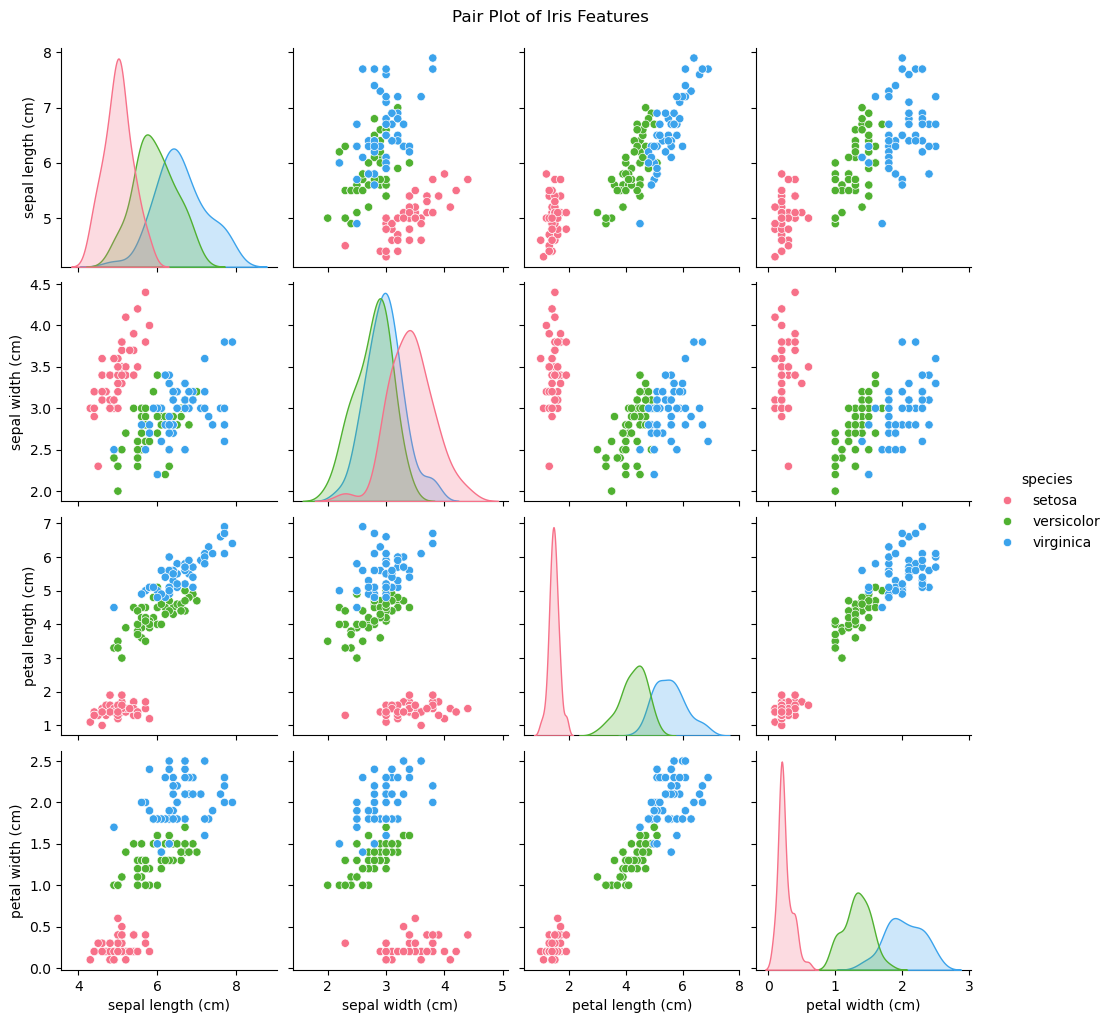

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

sns.pairplot(df, hue='species', palette='husl')
plt.suptitle('Pair Plot of Iris Features', y=1.02)

# 保存到本地目录（适合 Windows）
plt.savefig('iris_pairplot.png', bbox_inches='tight')
plt.show()
#What your code does

#Loads the Iris dataset (4 features, 3 classes)

#Uses seaborn pairplot() to draw scatter plots of every pair of features

#Colors the points by species

#Lets you visually see how well the classes are separated





C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


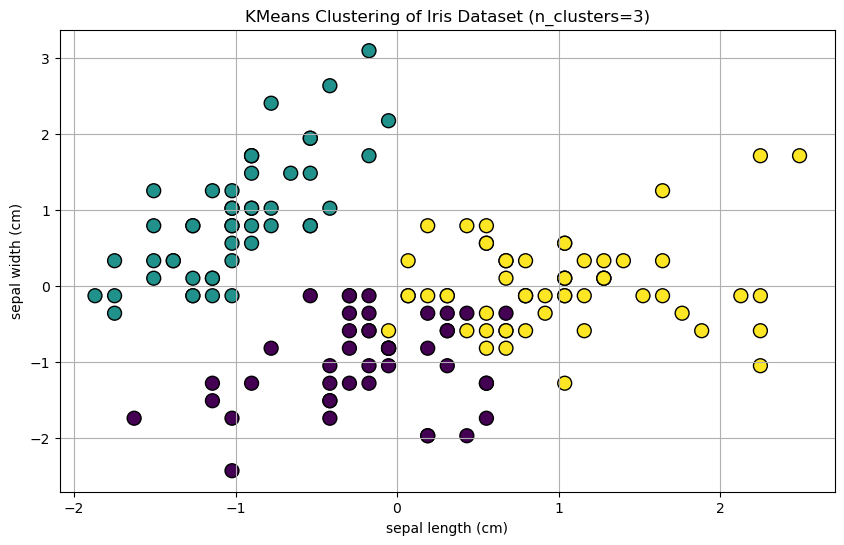

KMeans plot saved: iris_kmeans_3_clusters.png


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = iris.data
y = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 根据你的学号 241117651，最后一位为 1 → 3 clusters
n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters, random_state=1)
kmeans.fit(X_scaled)

df_plot = pd.DataFrame(X_scaled, columns=iris.feature_names)
df_plot['Cluster'] = kmeans.labels_

plt.figure(figsize=(10,6))
plt.scatter(df_plot.iloc[:,0], df_plot.iloc[:,1],
            c=df_plot['Cluster'], cmap='viridis',
            marker='o', edgecolor='k', s=100)

plt.title('KMeans Clustering of Iris Dataset (n_clusters=3)')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.grid()

# 保存图片到当前目录
plt.savefig('iris_kmeans_3_clusters.png', bbox_inches='tight')
plt.show()

print("KMeans plot saved: iris_kmeans_3_clusters.png")

#KMeans is an unsupervised algorithm.
#It groups samples based only on similarity, without knowing labels.
#Since my student ID ends with 1, I used 3 clusters.
#The result shows 3 groups, although they may not perfectly match the true classes.



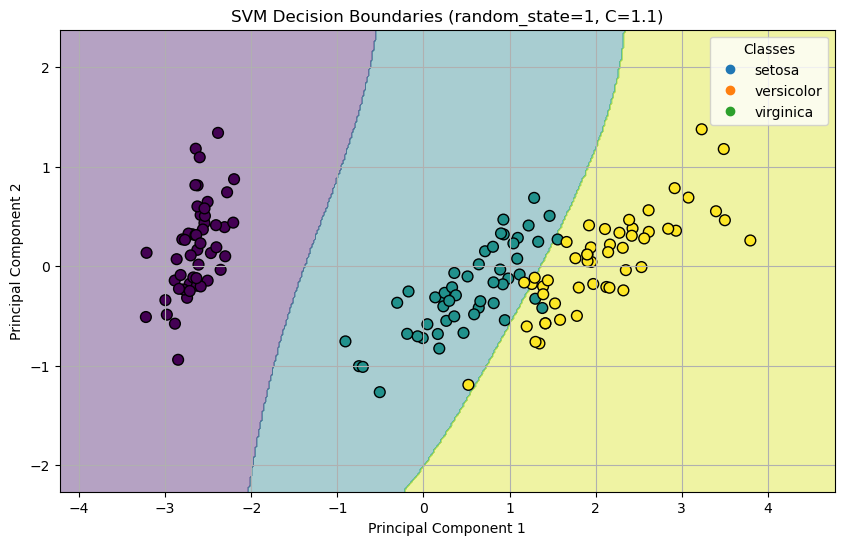

Accuracy = 0.96


In [11]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# 加载数据
iris = load_iris()
features = iris.data
y = iris.target

# 学号最后一位 = 1
random_state = 1
C_value = 1.0 + 1/10.0   # = 1.1

# PCA
pca = PCA(n_components=2, random_state=random_state)
principal_components = pca.fit_transform(features)
#Apply PCA to reduce 4 features → 2 components
#“To reduce dimensionality and make the SVM decision boundaries visualizable in 2D.”

#“Higher C means fewer misclassifications but may lead to overfitting.

# SVM 分类
clf = SVC(C=C_value, random_state=random_state)
clf.fit(principal_components, y)

# 网格区域用于画决策边界
x_min, x_max = principal_components[:,0].min() - 1, principal_components[:,0].max() + 1
y_min, y_max = principal_components[:,1].min() - 1, principal_components[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, alpha=0.4)

# 数据点
scatter = plt.scatter(principal_components[:,0], principal_components[:,1],
                      c=y, edgecolor='k', s=60)

# ---- 修复 Legend：手动生成（不会再报错） ----
handles = []
labels = iris.target_names
colors = ['tab:blue', 'tab:orange', 'tab:green']

for i, label in enumerate(labels):
    handles.append(plt.Line2D([], [], marker="o", linestyle="", 
                              color=colors[i], label=label))

plt.legend(handles=handles, title="Classes")

# ------------------------------------------------

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('SVM Decision Boundaries (random_state=1, C=1.1)')
plt.grid()

# 保存图片
plt.savefig('pca_svm_qmul1.png', bbox_inches='tight')
plt.show()

# 准确率
y_pred = clf.predict(principal_components)
accuracy = accuracy_score(y, y_pred)
print("Accuracy =", accuracy)





In [12]:
from transformers import pipeline

prompt = "How can AI revolutionize the healthcare industry?"

# GPT-2 生成器
gpt2_generator = pipeline("text-generation", model="gpt2")

gpt2_output = gpt2_generator(
    prompt,
    max_length=200,
    num_return_sequences=1,
    temperature=0.7,
)

gpt2_text = gpt2_output[0]["generated_text"]

print("GPT-2 OUTPUT:\n")
print(gpt2_text)

# 保存输出
with open("gpt2_output.txt", "w", encoding="utf-8") as f:
    f.write(gpt2_text)

print("\nSaved to gpt2_output.txt")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


GPT-2 OUTPUT:

How can AI revolutionize the healthcare industry?

A key assumption of AI research is that human beings will become more adept at understanding the world around them. This is an assumption that has been largely supported by large-scale research projects and the field of artificial intelligence.

A number of different approaches have been used to measure human intelligence. The most widely used is the Minkowski–Mendel model, which measures the brain's ability to process information. Minkowski is a mathematical concept that is used to measure the brain's ability to process information. Most commonly, cognitive tasks are designed to measure brain activity, such as processing short images and learning new words. The Minkowski-Mendel model is the most widely used. In other words, the Minkowski-Mendel model is the best way to measure brain activity in a human being.

The Minkowski–Mendel model is the best way to measure brain activity in a human being. It shows how brain activ

In [13]:
from transformers import pipeline

prompt = "How can AI revolutionize the healthcare industry?"

gptneo_generator = pipeline("text-generation", model="EleutherAI/gpt-neo-125M")

gptneo_output = gptneo_generator(
    prompt,
    max_length=200,
    num_return_sequences=1,
    temperature=0.7,
)

gptneo_text = gptneo_output[0]["generated_text"]

print("GPT-Neo OUTPUT:\n")
print(gptneo_text)

# 保存输出
with open("gptneo_output.txt", "w", encoding="utf-8") as f:
    f.write(gptneo_text)

print("\nSaved to gptneo_output.txt")


config.json: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/526M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


GPT-Neo OUTPUT:

How can AI revolutionize the healthcare industry?

A:

It's been a long time since I wrote a lot about the healthcare industry, but I think it has been an exciting year.
There are many ways you can make a revolution in the healthcare industry, and some of them have been proven to be successful.
Some of the most successful ways to make a revolution in healthcare include:

Improving the quality of the healthcare system by introducing new types of technology

Improving healthcare systems by introducing new types of technologies

Improving healthcare systems by introducing new types of technologies

Improving healthcare systems by introducing new types of technologies

Improving healthcare systems by introducing new types of technologies

Improving infrastructure by introducing new types of technologies

Improving infrastructure by introducing new types of technologies

Improving infrastructure by introducing new types of technologies

Improving healthcare systems by intro

In [14]:
from transformers import pipeline

prompt = "How can AI revolutionize the healthcare industry?"

xlnet_generator = pipeline("text-generation", model="xlnet-base-cased")

xlnet_output = xlnet_generator(
    prompt,
    max_length=200,
    num_return_sequences=1,
)

xlnet_text = xlnet_output[0]["generated_text"]

print("XLNet OUTPUT:\n")
print(xlnet_text)

# 保存输出
with open("xlnet_output.txt", "w", encoding="utf-8") as f:
    f.write(xlnet_text)

print("\nSaved to xlnet_output.txt")


config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Both `max_new_tokens` (=256) and `max_length`(=365) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
This is a friendly reminder - the current text generation call has exceeded the model's predefined maximum length (-1). Depending on the model, you may observe exceptions, performance degradation, or nothing at all.


model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

XLNet OUTPUT:

How can AI revolutionize the healthcare industry?AI revolutionizes the healthcare industry? How can AI revolutionize the healthcare industry? How can AI revolutionize the healthcare industry? How can AI revolutionize the healthcare industry? How can AI revolutionize the healthcare industry? How can AI revolutionize the healthcare industry? How can AI revolutionize the healthcare industry? How can AI revolutionize the healthcare industry? How can AI revolutionize the healthcare industry? How can AI revolutionize the healthcare industry? How can AI revolutionize the healthcare industry? How can AI revolutionize the healthcare industry? How can AI revolutionize the healthcare industry? How can AI revolutionize the healthcare industry? How can AI revolutionize the healthcare industry? How can AI revolutionize the healthcare industry? How can AI revolutionize the healthcare industry? How can AI revolutionize the healthcare industry? How can AI revolutionize the healthcare ind